<a href="https://colab.research.google.com/github/radhikash21/Bootcamp_ML_Notebooks/blob/main/session5_S6_batch2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)


print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [8]:
print("Missing values in each column:")
print(df.isna().sum())

print("Number of duplicate rows:",df.duplicated().sum())

Missing values in each column:
country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64
Number of duplicate rows: 0


In [9]:
#using pandas-create a basic data analysis print year range,number of countries,number of continents
year_min = df['year'].min()
year_max = df['year'].max()

print(f"Year Range: {year_min} - {year_max}")

num_countries = df['country'].nunique()

print(f"Number of Countries: {num_countries}")

num_continents = df['continent'].nunique()

print(f"Number of Continents: {num_continents}")

Year Range: 1952 - 2007
Number of Countries: 142
Number of Continents: 5


In [10]:
#groups and counts-gdp population life expectancy
df_clean=df.copy()
print(df_clean["continent"].value_counts())

continent_summary=df_clean.groupby("continent")[["lifeExp", "gdpPercap", "pop"]].mean()
print(continent_summary)
#feature extraction

continent
Africa      624
Asia        396
Europe      360
Americas    300
Oceania      24
Name: count, dtype: int64
             lifeExp     gdpPercap           pop
continent                                       
Africa     48.865330   2193.754578  9.916003e+06
Americas   64.658737   7136.110356  2.450479e+07
Asia       60.064903   7902.150428  7.703872e+07
Europe     71.903686  14469.475533  1.716976e+07
Oceania    74.326208  18621.609223  8.874672e+06


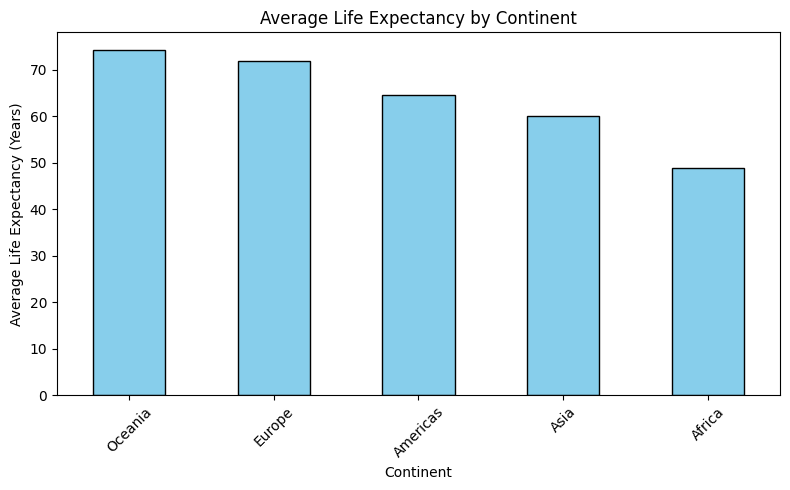

In [11]:
# Create bar chart
plt.figure(figsize=(8, 5))
avg_life_exp = df.groupby('continent')['lifeExp'].mean().sort_values(ascending=False)
avg_life_exp.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average Life Expectancy by Continent')
plt.xlabel('Continent')
plt.ylabel('Average Life Expectancy (Years)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

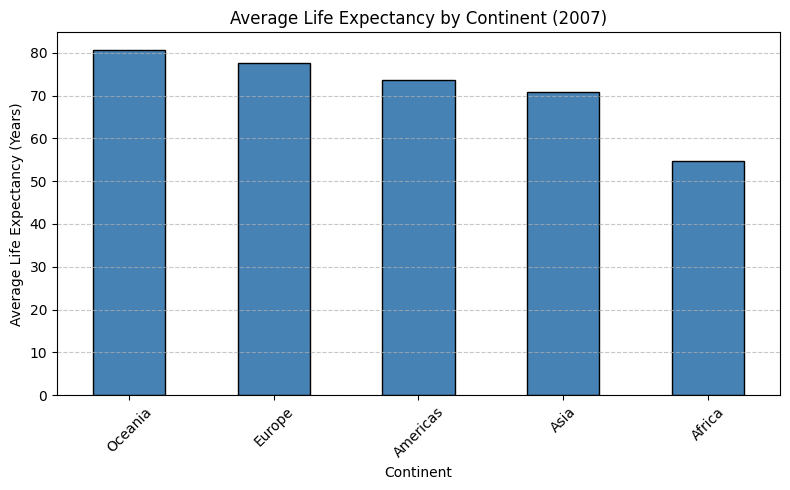

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Find the latest year
latest_year = df['year'].max()

# Filter data for the latest year
latest_data = df[df['year'] == latest_year]

# Calculate average life expectancy by continent
avg_life_exp = (
    latest_data
    .groupby('continent')['lifeExp']
    .mean()
    .sort_values(ascending=False)
)

# Create bar chart
plt.figure(figsize=(8, 5))
avg_life_exp.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title(f'Average Life Expectancy by Continent ({latest_year})')
plt.xlabel('Continent')
plt.ylabel('Average Life Expectancy (Years)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

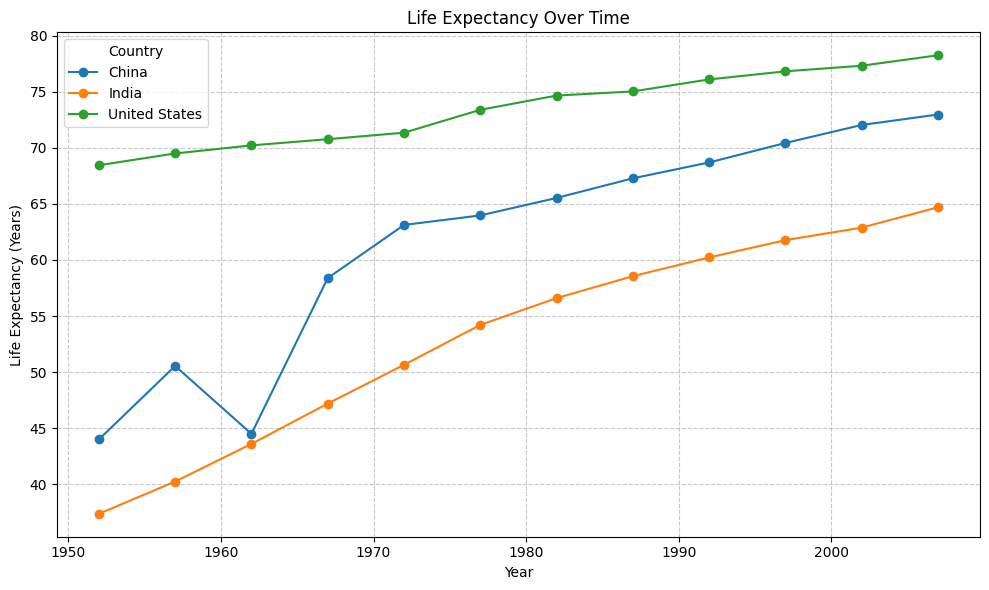

In [13]:
import matplotlib.pyplot as plt

countries = ['India', 'China', 'United States']

pivot_df = (
    df[df['country'].isin(countries)]
    .pivot(index='year', columns='country', values='lifeExp')
)

pivot_df.plot(
    figsize=(10, 6),
    marker='o'
)

plt.title('Life Expectancy Over Time')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

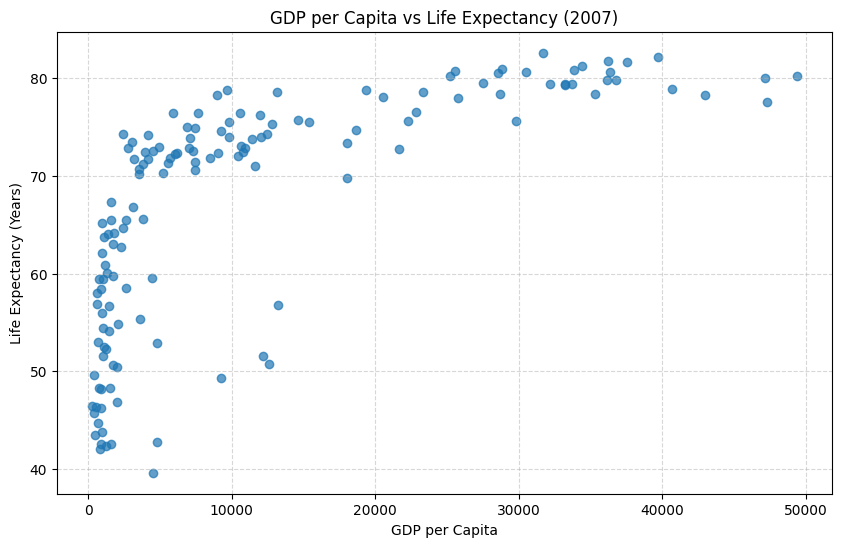

In [14]:
latest_year = df['year'].max()

latest_df = df[df['year'] == latest_year]

plt.figure(figsize=(10, 6))

plt.scatter(
    latest_df['gdpPercap'],
    latest_df['lifeExp'],
    alpha=0.7
)

plt.title(f'GDP per Capita vs Life Expectancy ({latest_year})')
plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()